## Wi-Fi Sensing
### Imports de bibliotecas

In [107]:
# pandas for data manipulation
import pandas as pd

# numpy for numerical operations
import numpy as np

# pyplot for plotting
import matplotlib.pyplot as plt

# re for regular expressions
import re

# sklearn for machine learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import sklearn as skl

# joblib for saving/loading models
import joblib

# other .py files
from csv_import import get_csv_files

# seaborn for advanced plotting
import seaborn as sns

### Retrieve CSV files

In [ ]:
path = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project\\CSI DATA D&M"

files_csi, files_diana, files_afinar = get_csv_files(path)

In [ ]:
def print_useful_info(file):
	# Print information about the files dictionaries
	print("Número de ficheiros recolhidos em ", file, ":", len(file))
	print("ESPs por cenário:", len(next(iter(file.values()))))

	# Print all scenarios names
	print("\nTodos os cenários:", sorted(file.keys()))

	# Count scenarios by letter prefix
	scenario_prefixes = {}
	for scenario in file:
		prefix = scenario[0]
		scenario_prefixes[prefix] = scenario_prefixes.get(prefix, 0) + 1

	print("\nScenarios count by prefix:")
	for prefix, count in sorted(scenario_prefixes.items()):
		print(f"Prefix {prefix}: {count} scenarios")

	print("\n")

In [ ]:
print_useful_info(files_csi)
print_useful_info(files_diana)
print_useful_info(files_afinar)

### Process ficheiros CSV

#### Tabela magnitudes

In [ ]:
# função que processo o arquivo CSV completo
# # e extrai a info da coluna do CSI
# # converte em números complexos
# # calcula a magnitude (2.º passo)
# # 
# e faz ainda uma 1a limpeza
# # remove 2 primeiras subportadoras
# # remove colunas a zero
# # aplica FFT shift

# da tese
# # Vector size verification
# # Subcarrier layout and magnitude computation

def process_csi(file):
    df = pd.read_csv(file, header=None)
    csi_col = df.iloc[:, 26]

    valid_csi = []
    for entry in csi_col:
        match = re.search(r'\[(.*?)\]', str(entry))
        if not match:
            continue
        nums = [float(n) for n in re.findall(r'-?\d+', match.group(1))]
        if len(nums) == 128:
            valid_csi.append(nums)

    valid_csi = np.array(valid_csi)
    complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]
    magnitudes = np.abs(complex_csi)

    # Limpeza: remover 2 primeiras subportadoras e colunas todas-zero
    magnitudes = magnitudes[:, 2:]
    magnitudes = magnitudes[:, ~np.all(magnitudes == 0, axis=0)]
    magnitudes = np.fft.fftshift(magnitudes, axes=1)

    return magnitudes

# cria o dict magnitudes
# itera sobre cada posicao da grelha
# # para cada posicao, itera sobre cada esp_id e path
# # devolve o dict magnitudes preenchido
def process_magnitudes(file):
    
    magnitudes = {}

    for posicao_grelha in file:
        magnitudes[posicao_grelha] = {}
        
        # dict com "esp_id" e "path"
        esps_do_posicao = file[posicao_grelha]
        
        for esp_id, ficheiro in esps_do_posicao.items():
            dados_processados = process_csi(ficheiro)
            magnitudes[posicao_grelha][esp_id] = dados_processados

    return magnitudes

# o dict magnitudes fica
# posicao1
# # esp1
# # # array de arrays (cada leitura é um array)
# # ...
# # esp4
# # # array de arrays (cada leitura é um array)

In [ ]:
magnitudes = process_magnitudes(files_csi)
magnitudes_diana = process_magnitudes(files_diana)
magnitudes_afinadas = process_magnitudes(files_afinar)

#### Cálculo da média

In [ ]:
# cálculo das médias das subportadoras

# função que extrai valores de determiada subportadora
# # recolhe apenas uma fracção dos valores (1/6 * nº leituras)
# # e devolve um dicionário com os resultados
# # # dict esp: array de valores
def extrai_valores_sc(magnitudes_dict, posicao, subcarrier_index, frac):
    resultados = {}
    for esp, matriz in magnitudes_dict[posicao].items():
        n = int(matriz.shape[0] * frac)
        resultados[esp] = matriz[:n, subcarrier_index]
    return resultados

# função que calcula a média dos valores extraídos na função de cima
# retorna um dict com 
# # esp: média
def calcular_media_sc(subportadora_dict):
    return {esp: np.mean(valores) for esp, valores in subportadora_dict.items()}

# função que calcula a média para cada subportadora
# # para cada sc
# # extrai os (n * frac) primeiros valores de cada esp
# # calcula a sua média 
# # # devolve um dict com
# # # subcarrier: {esp_y: média}
def calcular_medias_para_varias_subportadoras(magnitudes_dict, posicao, subcarrier_indices, frac):
    medias_por_subc = {}
    for subc in subcarrier_indices:
        valores = extrai_valores_sc(magnitudes_dict, posicao, subc, frac)
        medias = calcular_media_sc(valores)
        medias_por_subc[subc] = medias
    return medias_por_subc

In [ ]:
# Grupo: c06
#   esp: (nº leituras, nº subportadoras)
#   esp1: (76, 51) # 76 é matriz.shape[0]
#   esp2: (71, 51)
#   esp3: (79, 51)
#   esp4: (99, 51)

# posição para retirar normalizações - escolha ARBITRÁRIA (explorar outras opções?)
posicao = 'c06'

# inicializa lista de subportadoras e números de ESPs
subcarriers = list(range(51))
esp_id = [1, 2, 3, 4]

# fração dos valores a considerar - porquê este valor?
frac = 1/6

medias_c06 = calcular_medias_para_varias_subportadoras(magnitudes, posicao, subcarriers, frac)
# para a posição c06
# # para a subcarrier_x
# # # esp1: média
# # # esp2: média
# # # esp3: média
# # # esp4: média

# Gera o dicionário final no formato usado no Raspberry Pi
# normalization_means_full = {
#     esp: {
#         subc: medias_c06[subc][f"esp{esp}"]
#         for subc in range(51)
#     }
#     for esp in esp_id
# }
#joblib.dump(normalization_means_full, 'normalization_means_full.pkl')

#### Tabela dados

Criar dataset "dados" (sc x posição) (array)

Ao invés de "magnitudes" (posição x esp) (array de arrays)


In [ ]:
# Parâmetros
N = 90
M = 350
O = 60
A = 292
I = 200

tamanhos = {
    'sem_pessoa': M, 'sem_pessoa_1': M,
    'a00': N, 'c05': N, 'a01': N, 'c06': N,
    'a09': N, 'c07': N, 'a10': N, 'c08': N,
    'a11': N, 'c09': N, 'b00': N, 'c10': N,
    'b01': N, 'c11': N, 'b02': N, 'd01': N,
    'b03': N, 'd02': N, 'b04': N, 'd03': N,
    'b05': N, 'd04': N, 'b06': N, 'd05': N,
    'b07': N, 'd06': N, 'b08': N, 'd07': N,
    'b09': N, 'd08': N, 'b10': N, 'd09': N,
    'b11': N, 'd10': N, 'c01': N, 'd11': N,
    'c02': N, 'e04': N, 'c03': N, 'e05': N,
    'c04': N, 'e06': N,
}

tamanhos_diana = {
    'sem_pessoa': M, 'sem_pessoa_1': M,
    'a00': O, 'c05': O, 'a01': O, 'c06': O,
    'a09': O, 'c07': O, 'a10': O, 'c08': O,
    'a11': O, 'c09': O, 'b00': O, 'c10': O,
    'b01': O, 'c11': O, 'b02': O, 'd01': O,
    'b03': O, 'd02': O, 'b04': O, 'd03': O,
    'b05': O, 'd04': O, 'b06': O, 'd05': O,
    'b07': O, 'd06': O, 'b08': O, 'd07': O,
    'b09': O, 'd08': O, 'b10': O, 'd09': O,
    'b11': O, 'd10': O, 'c01': O, 'd11': O,
    'c02': O, 'e04': O, 'c03': O, 'e05': O,
    'c04': O, 'e06': O,
}

tamanhos_afinar = {
    'com_pessoa': A, 'sem_pessoa': A, 'com_pessoa_2': I, 'sem_pessoa_2': I,
}

posicoes = ['sem_pessoa', 'sem_pessoa_1', 'a00', 'a01', 'a09', 'a10', 'a11', 'b00', 'b01', 'b02',
        'b03', 'b04', 'b05', 'b06', 'b07', 'b08', 'b09', 'b10', 'b11', 'c01', 'c02', 'c03',
        'c04', 'c05', 'c06', 'c07', 'c08', 'c09', 'c10', 'c11', 'd01', 'd02', 'd03',
        'd04', 'd05', 'd06', 'd07', 'd08', 'd09', 'd10', 'd11', 'e04', 'e05', 'e06']

posicoes_afinar = ['sem_pessoa', 'sem_pessoa_2', 'com_pessoa', 'com_pessoa_2']

In [ ]:
# para cada posição
# # ver o tamanho de cada (auto definido em cima)
# # e para cada subportadora
# # # e para cada esp
# # # # extrair o vetor correto
# # # # guardar no dicionário
def criar_dataset(posicoes, tamanhos, magnitudes):
    dados = {subc: {} for subc in subcarriers}
    for posicao in posicoes:
        tam = tamanhos[posicao]
        print("tamanho = ", tam, ", posição = ", posicao)
        for subc in subcarriers:
            for i in esp_id:
                # acede ao array de arrays
                matriz = magnitudes[posicao][f'esp{i}']
                # extrai o vetor coluna
                # com (linhas/leituras = tam)
                # com (coluna = subc)
                vetor = matriz[:tam, subc]
                #print("nº linhas = ", matriz.shape[0], " e tam = ", tam)
                chave = f"{posicao}_{i}"
                dados[subc][chave] = vetor

    return dados

In [ ]:
dados = criar_dataset(posicoes, tamanhos, magnitudes)
dados_diana = criar_dataset(posicoes, tamanhos_diana, magnitudes_diana)
dados_afinar = criar_dataset(posicoes_afinar, tamanhos_afinar, magnitudes_afinadas)

In [ ]:
print(len(dados[35]["sem_pessoa_1"]))
print(len(dados[35]["a00_1"]))

#### Tabela normalizados

Normalização de dados

In [ ]:
# Função para normalizar
# a função recebe o dicionário de vetores e o dicionário de médias
# e devolve o dicionário de vetores normalizados
# cada vetor é normalizado subtraindo a média e dividindo pela média
def normalizar_vetores(vetores_dict, medias_dict):
    normalizados = {f"subcarrier_{subc}": {} for subc in subcarriers}
    for subc in subcarriers:
        for posicao in posicoes:
            for id in esp_id:
                chave = f"{posicao}_{id}"
                esp = f"esp{id}"
                vetor = vetores_dict[subc][chave]
                media = medias_dict[subc][esp]
                normalizados[f"subcarrier_{subc}"][chave] = (vetor - media) / media
    return normalizados

# Função para normalizar dados a afinar
def normalizar_vetores_afinar(vetores_dict, medias_dict):
    normalizados = {f"subcarrier_{subc}": {} for subc in subcarriers}
    for subc in subcarriers:
        for posicao in posicoes_afinar:
            for id in esp_id:
                chave = f"{posicao}_{id}"
                esp = f"esp{id}"
                vetor = vetores_dict[subc][chave]
                media = medias_dict[subc][esp]
                normalizados[f"subcarrier_{subc}"][chave] = (vetor - media) / media
    return normalizados

In [ ]:
normalizados_loureiro = normalizar_vetores(dados, medias_c06)
normalizados_diana = normalizar_vetores(dados_diana, medias_c06)
normalizados_afinar = normalizar_vetores_afinar(dados_afinar, medias_c06)


In [ ]:
print(len(normalizados_loureiro["subcarrier_34"]["sem_pessoa_1"]))
print(len(normalizados_loureiro["subcarrier_0"]["a00_1"]))

#### Cálculo mean, std, max

Média, desvio padrão e valor máximo

In [ ]:
# função para calcular a média em janelas sobrepostas
def media_grupos_overlap(vetor, tamanho_janela, step):
    medias = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        medias.append(np.mean(janela))
    return np.array(medias)

# função para calcular o desvio padrão em janelas sobrepostas
def std_grupos_overlap(vetor, tamanho_janela, step):
    desvios = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        desvios.append(np.std(janela))
    return np.array(desvios)

# função para calcular o máximo em janelas sobrepostas,
# evitando repetições dos últimos 3 máximos escolhidos
def max_grupos_overlap(vetor, tamanho_janela, step):
    maximos = []

    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        candidatos = np.sort(np.unique(janela))[::-1]  # do maior para o menor

        # Exclui os 3 últimos valores
        ultimos = set(maximos[-3:])

        escolhido = None
        for val in candidatos:
            if val not in ultimos:
                escolhido = val
                break

        # Se todos os valores estão nos últimos 3, aceita o maior mesmo assim
        if escolhido is None:
            escolhido = candidatos[0]

        maximos.append(escolhido)

    return np.array(maximos)

In [ ]:
def media_fixed(vetor, tamanho_janela, W):
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return media_grupos_overlap(vetor, tamanho_janela, step)[:W]

def std_fixed(vetor, tamanho_janela, W):
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return std_grupos_overlap(vetor, tamanho_janela, step)[:W]

def max_fixed(vetor, tamanho_janela, W):
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return max_grupos_overlap(vetor, tamanho_janela, step)[:W]


def media_fixed_af(vetor, tamanho_janela, G):
    step = (len(vetor) - tamanho_janela) // (G - 1)
    return media_grupos_overlap(vetor, tamanho_janela, step)[:G]

def std_fixed_af(vetor, tamanho_janela, G):
    step = (len(vetor) - tamanho_janela) // (G - 1)
    return std_grupos_overlap(vetor, tamanho_janela, step)[:G]

def max_fixed_af(vetor, tamanho_janela, G):
    step = (len(vetor) - tamanho_janela) // (G - 1)
    return max_grupos_overlap(vetor, tamanho_janela, step)[:G]

In [ ]:
# --- Médias: sem_pessoa mantém step=3, outros usam media_fixed ---
tamanho_janela = 10
step = 3
W = 27   # nº de janelas fixas para "com pessoa"
G = 60   # nº de janelas fixas para "dados_afinar"

media_loureiro = {subc: {} for subc in subcarriers}
media_diana    = {subc: {} for subc in subcarriers}
media_afinar   = {subc: {} for subc in subcarriers}

std_loureiro = {subc: {} for subc in subcarriers}
std_diana    = {subc: {} for subc in subcarriers}
std_afinar   = {subc: {} for subc in subcarriers}

max_loureiro = {subc: {} for subc in subcarriers}
max_diana    = {subc: {} for subc in subcarriers}
max_afinar   = {subc: {} for subc in subcarriers}

for grupo in posicoes:
    for id in esp_id:
        chave = f"{grupo}_{id}"
        for subc in subcarriers:
            v_l = normalizados_loureiro[f"subcarrier_{subc}"][chave]
            v_d = normalizados_diana[f"subcarrier_{subc}"][chave]

            if grupo.startswith("sem_pessoa"):
                # mantém todas as janelas possíveis, sem truncar
                media_l = media_grupos_overlap(v_l, tamanho_janela, step)
                std_l = std_grupos_overlap(v_l, tamanho_janela, step)
                m_l = max_grupos_overlap(v_l, tamanho_janela, step)
                
                media_d = media_grupos_overlap(v_d, tamanho_janela, step)
                std_d = std_grupos_overlap(v_d, tamanho_janela, step)
                m_d = max_grupos_overlap(v_d, tamanho_janela, step)
            else:
                # força W janelas idênticas
                media_l = media_fixed(v_l, tamanho_janela, W)
                std_l = std_fixed(v_l, tamanho_janela, W)
                m_l = max_fixed(v_l, tamanho_janela, W)

                media_d = media_fixed(v_d, tamanho_janela, W)
                std_d = std_fixed(v_d, tamanho_janela, W)
                m_d = max_fixed(v_d, tamanho_janela, W)

            media_loureiro[subc][chave] = media_l
            std_loureiro  [subc][chave] = std_l
            max_loureiro  [subc][chave] = m_l

            media_diana [subc][chave] = media_d
            std_diana   [subc][chave] = std_d
            max_diana   [subc][chave] = m_d

for grupo in posicoes_afinar:
    for id in esp_id:
        chave = f"{grupo}_{id}"
        for subc in subcarriers:
            v = normalizados_afinar [f"subcarrier_{subc}"][chave]
            media = media_fixed_af(v, tamanho_janela, G)
            std = std_fixed_af(v, tamanho_janela, G)
            max = max_fixed_af(v, tamanho_janela, G)

            media_afinar[subc][chave] = media
            std_afinar[subc][chave] = std
            max_afinar[subc][chave] = max

In [132]:
print(len(media_loureiro[34]["sem_pessoa_1"]))
print(len(media_loureiro[0]["a00_1"]))

114
27


#### Tabela colunas

In [119]:
subcarriers_map = {i + 1: sub for i, sub in enumerate(subcarriers)}

# dicionários para guardar cada coluna
col_media, col_std, col_max = {}, {}, {}

# dicionários para guardar cada coluna
col_media_afinar, col_std_afinar, col_max_afinar = {}, {}, {}

for subc_label, subc in subcarriers_map.items():
    for esp in esp_id:
        # nome da coluna
        name_mean = f"Mean sc{subc_label} esp{esp}"
        name_std  = f"Std sc{subc_label} esp{esp}"
        name_max  = f"Max sc{subc_label} esp{esp}"

        seq_mean, seq_std, seq_max = [], [], []

        # 1) SEM PESSOA: primeiro Loureiro, depois Diana
        seq_mean.append(media_loureiro[subc][f"sem_pessoa_{esp}"])
        seq_mean.append(media_loureiro[subc][f"sem_pessoa_1_{esp}"])

        seq_mean.append(media_diana[subc][f"sem_pessoa_{esp}"])
        seq_mean.append(media_diana[subc][f"sem_pessoa_1_{esp}"])

        seq_std.append(std_loureiro[subc][f"sem_pessoa_{esp}"])
        seq_std.append(std_loureiro[subc][f"sem_pessoa_1_{esp}"])

        seq_std.append(std_diana[subc][f"sem_pessoa_{esp}"])
        seq_std.append(std_diana[subc][f"sem_pessoa_1_{esp}"])

        seq_max.append(max_loureiro[subc][f"sem_pessoa_{esp}"])
        seq_max.append(max_loureiro[subc][f"sem_pessoa_1_{esp}"])

        seq_max.append(max_diana[subc][f"sem_pessoa_{esp}"])
        seq_max.append(max_diana[subc][f"sem_pessoa_1_{esp}"])


        # 2) COM PESSOA: percorre todos os outros grupos
        
        # GRALHA CÓDIGO ORIGINAL
        # # o "if" apenas server para o grupo "sem pessoa" e não para "sem_pessoa_1"
        for grupo in posicoes:
            if grupo.startswith("sem_pessoa"):
                continue
            key = f"{grupo}_{esp}"
            seq_mean.append(media_loureiro[subc][key])
            seq_mean.append(media_diana[subc][key])

            seq_std.append( std_loureiro[subc][key])
            seq_std.append( std_diana[subc][key])
            
            seq_max.append( max_loureiro[subc][key])
            seq_max.append( max_diana[subc][key])

        # 3) concatena e guarda
        col_media[name_mean] = np.concatenate(seq_mean)
        col_std [name_std ] = np.concatenate(seq_std)
        col_max [name_max ] = np.concatenate(seq_max)

for subc_label, subc in subcarriers_map.items():
    for esp in esp_id:
        # nome da coluna
        name_mean_af = f"Mean sc{subc_label} esp{esp}"
        name_std_af  = f"Std sc{subc_label} esp{esp}"
        name_max_af  = f"Max sc{subc_label} esp{esp}"

        seq_mean, seq_std, seq_max = [], [], []

        for grupo in posicoes_afinar:
            key = f"{grupo}_{esp}"

            seq_mean.append(media_afinar[subc][key])
            seq_std.append(std_afinar[subc][key])
            seq_max.append(max_afinar[subc][key])

        col_media_afinar[name_mean_af] = np.concatenate(seq_mean)
        col_std_afinar[name_std_af] = np.concatenate(seq_std)
        col_max_afinar[name_max_af] = np.concatenate(seq_max)

In [120]:
tamanho_loureiro = len(media_loureiro[1]["sem_pessoa_1"]) + len(media_loureiro[1]["sem_pessoa_1_1"]) + len(media_loureiro[1]["a00_1"]) * 42
print(len(media_loureiro[1]["sem_pessoa_1"]) + len(media_loureiro[1]["sem_pessoa_1_1"]))
print(tamanho_loureiro)

tamanhos_diana = len(media_diana[1]["sem_pessoa_1"]) + len(media_diana[1]["sem_pessoa_1_1"]) + len(media_diana[1]["a00_1"]) * 42
print(len(media_diana[1]["sem_pessoa_1"]) + len(media_diana[1]["sem_pessoa_1_1"]))
print(tamanhos_diana)

total = tamanho_loureiro + tamanhos_diana
print(total)
print(len(col_media["Mean sc1 esp1"]))

161
1295
173
1307
2602
2602


#### Junta e trunca as colunas

In [121]:
all_cols = {**col_media, **col_std, **col_max}
min_len = min(len(v) for v in all_cols.values())

# trunca as colunas para o tamanho do menor vetor (min_len)
col_media = {k: v[:min_len] for k, v in col_media.items()}
col_std   = {k: v[:min_len] for k, v in col_std.items()}
col_max   = {k: v[:min_len] for k, v in col_max.items()}

# Gera o vetor de labels (0 = sem_pessoa, 1 = com_pessoa)
# o número de zeros é a soma dos tamanhos dos grupos "sem pessoa"
# tanto do Loureiro como da Diana
# # a subportadora 22 é escolhida arbitrariamente, pois todas têm o mesmo número de leituras
n_zero = sum([
    len(media_loureiro[22][f"sem_pessoa_{esp}"]) +
    len(media_loureiro[22][f"sem_pessoa_1_{esp}"]) +
    len(media_diana[22][f"sem_pessoa_{esp}"]) +
    len(media_diana[22][f"sem_pessoa_1_{esp}"])
    for esp in esp_id
])

# Total de linhas (após truncar tudo para min_len)
n_total = min_len

# Cria vetor target: 0 para "sem pessoa", 1 para "com pessoa"
target_vector = np.zeros(n_total, dtype=int)
target_vector[n_zero:] = 1  # a partir do índice n_zero, coloca 1 (com pessoa)

#### Dataframe

In [122]:
# DataFrame
df = pd.DataFrame({**col_media, **col_std, **col_max})
df['target'] = target_vector

print(df['target'].value_counts())
print(df.shape)

# descrever categorical columns
df.describe()

target
0    1453
1    1149
Name: count, dtype: int64
(2602, 613)


,Mean sc1 esp1,Mean sc1 esp2,Mean sc1 esp3,Mean sc1 esp4,Mean sc2 esp1,Mean sc2 esp2,Mean sc2 esp3,Mean sc2 esp4,Mean sc3 esp1,Mean sc3 esp2,...,Max sc49 esp4,Max sc50 esp1,Max sc50 esp2,Max sc50 esp3,Max sc50 esp4,Max sc51 esp1,Max sc51 esp2,Max sc51 esp3,Max sc51 esp4,target
count,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,...,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000,2602.000000
mean,-0.002895,0.409633,0.152326,0.012393,-0.041822,0.387035,0.273051,0.141312,-0.088252,0.318956,...,0.120465,0.204002,0.257261,0.013947,0.118075,0.159402,0.727393,0.493481,0.194106,0.441583
std,0.104957,0.398833,0.256587,0.138590,0.105030,0.349364,0.285512,0.179440,0.125333,0.277070,...,0.210163,0.219149,0.230393,0.213339,0.195826,0.160840,0.432871,0.434130,0.205258,0.496671
min,-0.400175,-0.570497,-0.574555,-0.395496,-0.418388,-0.535822,-0.548466,-0.359255,-0.501252,-0.512225,...,-0.292282,-0.502197,-0.706747,-0.925782,-0.280768,-0.392018,-0.726956,-0.461716,-0.254286,0.000000
25%,-0.050635,0.099046,-0.052687,-0.090809,-0.080666,0.114478,0.041572,0.006731,-0.157451,0.115397,...,-0.117806,0.113122,0.112819,-0.107835,-0.096475,0.049697,0.392259,0.136206,0.081528,0.000000
50%,0.007834,0.443826,0.105416,0.011684,-0.024408,0.430854,0.218736,0.150745,-0.075136,0.344896,...,0.186839,0.192989,0.266434,0.009479,0.172205,0.173597,0.717264,0.392592,0.175004,0.000000
75%,0.070824,0.756587,0.327156,0.117380,0.020083,0.684486,0.491241,0.278844,-0.000496,0.541070,...,0.294891,0.274420,0.415536,0.113276,0.277777,0.261579,1.020856,0.928205,0.252419,1.000000
max,0.349266,1.446976,0.990220,0.445587,0.242367,1.390318,1.184172,0.596477,0.314470,1.114364,...,1.247278,1.783707,1.578296,1.371507,1.307226,1.091530,2.459760,1.442768,1.988634,1.000000


### Machine Learning

#### Divisão treino/teste

In [123]:
# features
X = df.drop(columns = 'target').values

# target
y = df['target'].values

print("X.shape =", X.shape)
print("y.shape =", y.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 200
)

print("X_train.shape =", X_train.shape)
print("X_test.shape  =", X_test.shape)
print("y_train.shape =", y_train.shape)
print("y_test.shape  =", y_test.shape)


X.shape = (2602, 612)
y.shape = (2602,)
X_train.shape = (2081, 612)
X_test.shape  = (521, 612)
y_train.shape = (2081,)
y_test.shape  = (521,)


#### Random Forest Classifier

In [124]:
model = skl.ensemble.RandomForestClassifier(min_samples_split=4,
                                            min_samples_leaf=4,
                                            max_leaf_nodes=64,
                                            n_estimators=150,
                                            random_state = 200,
                                            max_depth=16,
                                            class_weight="balanced_subsample",
                                            criterion='entropy'
)

model = model.fit(X_train, y_train)

# pkl_path = path + "\\modelo_treinado.pkl"
# joblib.dump(model, pkl_path)
# print(f"Modelo guardado em: {pkl_path}")

In [125]:
pred_test = model.predict(X_test)

skl.metrics.balanced_accuracy_score(y_test, pred_test)

0.9714980312611861

#### Confusion Matrix

In [126]:
confusion_matrix_test = skl.metrics.confusion_matrix(y_test, pred_test)

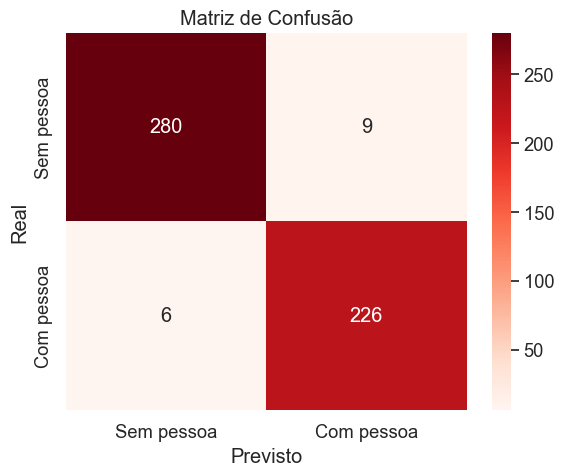

In [127]:
sns.set(font_scale=1.2)
plt.figure(figsize=(6, 5))

sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Reds',
            xticklabels=["Sem pessoa", "Com pessoa"],
            yticklabels=["Sem pessoa", "Com pessoa"])

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


In [ ]:
# pkl_path = path + "\\modelo_treinado.pkl"
# model = joblib.load(pkl_path)